In [136]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [137]:
# Load a specific output folder (recommended) OR auto-pick newest
from pathlib import Path
import time

# Option A (recommended): point directly to the newest run folder
OUTPUT_DIR = Path(r"C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-02-28_13-37-59")

# Basic guardrails
if not OUTPUT_DIR.exists():
    raise FileNotFoundError(f"OUTPUT_DIR does not exist: {OUTPUT_DIR}")

q_path = OUTPUT_DIR / "q_save.npy"
u_path = OUTPUT_DIR / "u_save.npy"
X_path = OUTPUT_DIR / "X_save.npy"
for p in [q_path, u_path, X_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

print("Using output:", OUTPUT_DIR)
print("q_save.npy mtime:", time.ctime(q_path.stat().st_mtime))
print("u_save.npy mtime:", time.ctime(u_path.stat().st_mtime))
print("X_save.npy mtime:", time.ctime(X_path.stat().st_mtime))

q = np.load(q_path)
u = np.load(u_path)
X = np.load(X_path)

# Load pendulum data if available
try:
    phi = np.load(OUTPUT_DIR / "phi_save.npy")
    phi_dot = np.load(OUTPUT_DIR / "phi_dot_save.npy")
    phi_ddot = np.load(OUTPUT_DIR / "phi_ddot_save.npy")
    has_pendulum_data = True
    print("Pendulum data loaded successfully")
except FileNotFoundError:
    has_pendulum_data = False
    print("No pendulum data found (older simulation format)")

params_path = OUTPUT_DIR / "params.json"
params = json.loads(params_path.read_text(encoding="utf-8")) if params_path.exists() else {}

print("q0 from file =", q[:, 0])
print("u0 from file =", u[:, 0])
if "q0" in params:
    print("params.json q0 =", params["q0"])
if "u0" in params:
    print("params.json u0 =", params["u0"])
for k in ["x0_input", "y0_input", "theta0_input", "omega0_input", "l_pendulum", "m_pendulum", "m_hoop"]:
    if k in params:
        print(f"params.json {k} =", params[k])

print("q shape:", q.shape)
print("u shape:", u.shape)
print("X shape:", X.shape)
if has_pendulum_data:
    print("phi shape:", phi.shape)

# Show a couple later states to confirm runs differ even when q0 matches
print("q[:,1] =", q[:, 1])
print("q[:,10] =", q[:, 10])


Using output: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-02-28_13-37-59
q_save.npy mtime: Sat Feb 28 13:38:18 2026
u_save.npy mtime: Sat Feb 28 13:38:18 2026
X_save.npy mtime: Sat Feb 28 13:38:18 2026
Pendulum data loaded successfully
q0 from file = [0.                 0.18               0.
 2.0943951023931953]
u0 from file = [0.                0.                0.                6.908723080762551]
params.json q0 = [0.0, 0.18, 0.0]
params.json u0 = [0.0, 0.0, 0.0]
params.json x0_input = 0.0
params.json y0_input = 0.18
params.json theta0_input = 0.0
params.json omega0_input = 0.0
params.json l_pendulum = 0.1
params.json m_pendulum = 0.1
params.json m_hoop = 1.0
q shape: (4, 1000)
u shape: (4, 1000)
X shape: (20, 1000)
phi shape: (1000,)
q[:,1] = [-1.0869921584615208e-06  1.7999999999999999e-01  7.8852633817087342e-06
  2.1377159071367062e+00]
q[:,10] = [-2.5160814830768136e-04  1.7999999999999999e-01  1.4135374803773634e-03
  2.52757541215

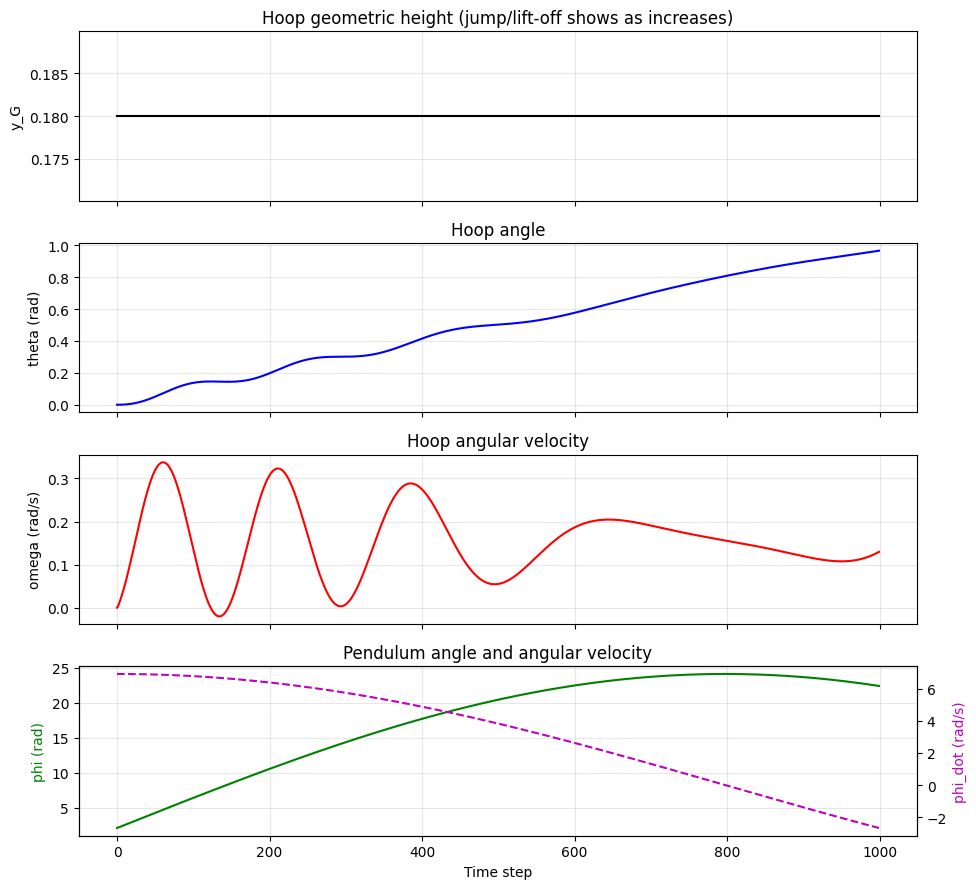

In [138]:
# Plot geometric height, angle, angular velocity, and pendulum angle
theta = q[2, :]
omega = u[2, :]
phi = q[3, :] if q.shape[0] > 3 else np.zeros_like(theta)
phi_dot = u[3, :] if u.shape[0] > 3 else np.zeros_like(omega)
yG = q[1, :]

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

axes[0].plot(yG, 'k-', linewidth=1.5)
axes[0].set_ylabel('y_G')
axes[0].set_title('Hoop geometric height (jump/lift-off shows as increases)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(theta, 'b-', linewidth=1.5)
axes[1].set_ylabel('theta (rad)')
axes[1].set_title('Hoop angle')
axes[1].grid(True, alpha=0.3)

axes[2].plot(omega, 'r-', linewidth=1.5)
axes[2].set_ylabel('omega (rad/s)')
axes[2].set_title('Hoop angular velocity')
axes[2].grid(True, alpha=0.3)

ax3b = axes[3].twinx()
axes[3].plot(phi, 'g-', linewidth=1.5, label='phi')
ax3b.plot(phi_dot, 'm--', linewidth=1.5, label='phi_dot')
axes[3].set_ylabel('phi (rad)', color='g')
ax3b.set_ylabel('phi_dot (rad/s)', color='m')
axes[3].set_xlabel('Time step')
axes[3].set_title('Pendulum angle and angular velocity')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

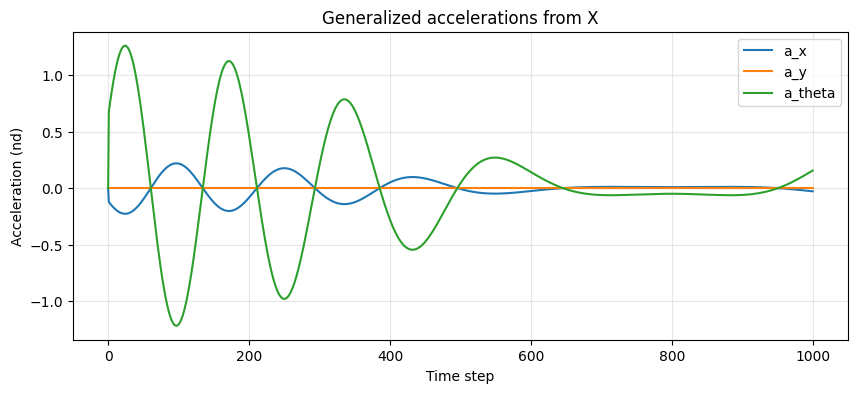

In [139]:
# Plot acceleration components from X array (a_x, a_y, a_theta) if present
if X.shape[0] >= 3:
    a_x = X[0, :]
    a_y = X[1, :]
    a_th = X[2, :]

    plt.figure(figsize=(10, 4))
    plt.plot(a_x, label='a_x')
    plt.plot(a_y, label='a_y')
    plt.plot(a_th, label='a_theta')
    plt.xlabel('Time step')
    plt.ylabel('Acceleration (nd)')
    plt.title('Generalized accelerations from X')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("X does not contain at least 3 acceleration components.")

[animation] Using output: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-02-28_13-37-59
[animation] q[:,0] = [0.                 0.18               0.
 2.0943951023931953]
Saving animation to: C:\Users\braid\OneDrive\Desktop\Bouncing Ball Generalized Alpha\outputs\hoop_pendulum_2026-02-28_13-37-59\hulahoop_motion_hoop_pendulum_2026-02-28_13-37-59.gif
Saved.


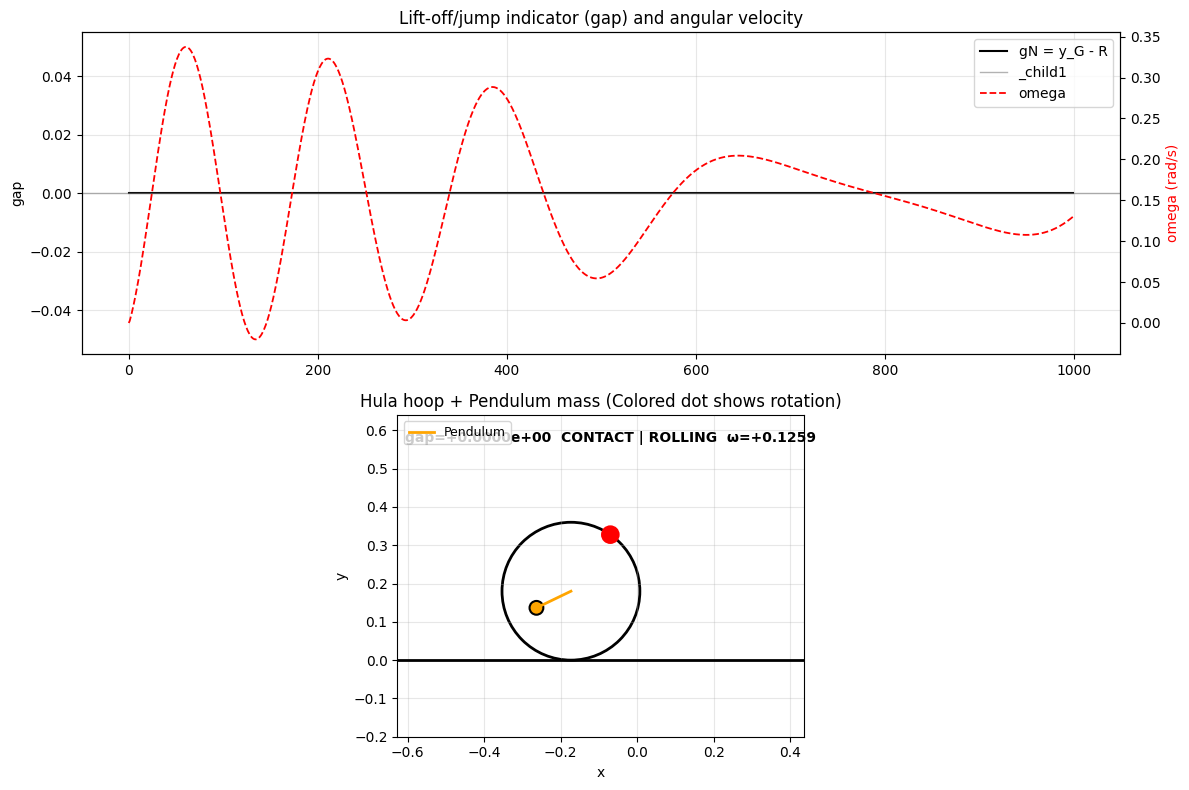

In [140]:
import matplotlib.animation as animation
from matplotlib.patches import Circle
from matplotlib.animation import PillowWriter

# Defensive reload: if you changed OUTPUT_DIR, rerunning *this* cell will still pick up the new data.
q = np.load(OUTPUT_DIR / "q_save.npy")
u = np.load(OUTPUT_DIR / "u_save.npy")
X = np.load(OUTPUT_DIR / "X_save.npy")
params_path = OUTPUT_DIR / "params.json"
params = json.loads(params_path.read_text(encoding="utf-8")) if params_path.exists() else {}
print("[animation] Using output:", OUTPUT_DIR)
print("[animation] q[:,0] =", q[:, 0])

# Load pendulum data if available
try:
    phi = np.load(OUTPUT_DIR / "phi_save.npy")
    has_pendulum = True
except FileNotFoundError:
    phi = np.zeros(q.shape[1])
    has_pendulum = False
    print("[animation] No pendulum data found; visualizing as fixed")

# Parameters (prefer saved params.json)
R = float(params.get("R", 0.1))
l_pendulum = float(params.get("l_pendulum", 0.5))

xG = q[0, :]
yG = q[1, :]
theta = q[2, :]
omega = u[2, :]  # Angular velocity for rotation detection

# Gap to ground (lift-off when > 0)
gN = yG - R

# Pendulum mass position (attached at hoop center, angle phi relative to global frame)
if has_pendulum:
    xP = xG + l_pendulum * np.cos(phi)
    yP = yG + l_pendulum * np.sin(phi)
else:
    xP = xG + l_pendulum * np.cos(np.zeros_like(theta))
    yP = yG + l_pendulum * np.sin(np.zeros_like(theta))

# Point on hoop rim (initially at +x direction relative to hoop center)
xR = xG + R * np.cos(theta)
yR = yG + R * np.sin(theta)

# ---- Figure layout ----
fig = plt.figure(figsize=(12, 8))

# 1) Time histories (gap and omega)
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(gN, 'k-', lw=1.5, label='gN = y_G - R')
ax1.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax1.set_ylabel('gap')
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(u[2, :], 'r--', lw=1.3, label='omega')
ax1b.set_ylabel('omega (rad/s)', color='r')
ax1.set_title('Lift-off/jump indicator (gap) and angular velocity')

# Combined legend
lines = ax1.get_lines() + ax1b.get_lines()
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc='upper right')

# 2) Animation
ax2 = fig.add_subplot(2, 1, 2)
ax2.set_aspect('equal')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Hula hoop + Pendulum mass (Colored dot shows rotation)')
ax2.grid(True, alpha=0.3)

# axis limits from data
xmin = float(min(np.min(xG), np.min(xP)) - 2 * R)
xmax = float(max(np.max(xG), np.max(xP)) + 2 * R)
ymin = -0.2
ymax = float(max(np.max(yG), np.max(yP)) + 2 * R)
ax2.set_xlim(xmin, xmax)
ax2.set_ylim(ymin, ymax)

# Ground line
ground_line, = ax2.plot([xmin, xmax], [0, 0], 'k-', lw=2)

# Hoop circle (centered at G)
hoop_circle = Circle((xG[0], yG[0]), R, fill=False, edgecolor='black', linewidth=2)
ax2.add_patch(hoop_circle)

# Colored point on hoop rim (initially blue - stationary)
rim_point = Circle((xR[0], yR[0]), 0.12 * R if R > 0 else 0.02, color='blue', ec='black', lw=1.5)
ax2.add_patch(rim_point)

# Pendulum mass marker
pend_patch = Circle((xP[0], yP[0]), 0.1 * R if R > 0 else 0.015, color='orange', ec='black', lw=1.5)
ax2.add_patch(pend_patch)

# Pendulum line from G to pendulum mass
pend_line, = ax2.plot([xG[0], xP[0]], [yG[0], yP[0]], 'orange', lw=2, label='pendulum')

# Text showing lift-off and rotation status
status_text = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, va='top', fontsize=10, fontweight='bold')

# Legend for markers
ax2.legend([pend_line], ['Pendulum'], loc='upper left', fontsize=9)

# Threshold for rotation detection
rotation_threshold = 0.01

def init():
    hoop_circle.center = (xG[0], yG[0])
    rim_point.center = (xR[0], yR[0])
    pend_patch.center = (xP[0], yP[0])
    pend_line.set_data([xG[0], xP[0]], [yG[0], yP[0]])
    status_text.set_text('')
    return hoop_circle, rim_point, pend_patch, pend_line, status_text

def animate(i):
    hoop_circle.center = (xG[i], yG[i])
    rim_point.center = (xR[i], yR[i])
    pend_patch.center = (xP[i], yP[i])
    pend_line.set_data([xG[i], xP[i]], [yG[i], yP[i]])
    
    # Change rim point color based on rotation: red if rotating, blue if stationary
    if abs(omega[i]) > rotation_threshold:
        rim_point.set_color('red')
        rotation_status = "ROLLING"
    else:
        rim_point.set_color('blue')
        rotation_status = "SLIDING"
    
    contact_status = 'AIR' if gN[i] > 1e-6 else 'CONTACT'
    status_text.set_text(f"gap={gN[i]:+.4e}  {contact_status} | {rotation_status}  ω={omega[i]:+.4f}")
    return hoop_circle, rim_point, pend_patch, pend_line, status_text

step = 5
frames = range(0, q.shape[1], step)
anim = animation.FuncAnimation(fig, animate, init_func=init, frames=frames, interval=20, blit=True)

# Optional: save GIF beside the output folder (unique per folder to avoid viewer caching)
gif_path = OUTPUT_DIR / f"hulahoop_motion_{OUTPUT_DIR.name}.gif"
print("Saving animation to:", gif_path)
writer = PillowWriter(fps=30)
anim.save(gif_path.as_posix(), writer=writer)
print("Saved.")

plt.tight_layout()
plt.show()

In [141]:
np.set_printoptions(precision=17, suppress=False)
print("Gap (gN) over time:")
print(gN[:])
print("\nHoop angle (theta) over time:")
print(q[2])
if has_pendulum_data:
    print("\nPendulum angle (phi) over time:")
    print(phi[:50])  # Show first 50 steps
    print("\nPendulum angular velocity (phi_dot):")
    print(phi_dot[:50])


Gap (gN) over time:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

gNdot shape: (1, 1000)
gNddot shape: (1, 1000)
lambdaN shape: (1, 1000)
lambdaF shape: (1, 1000)


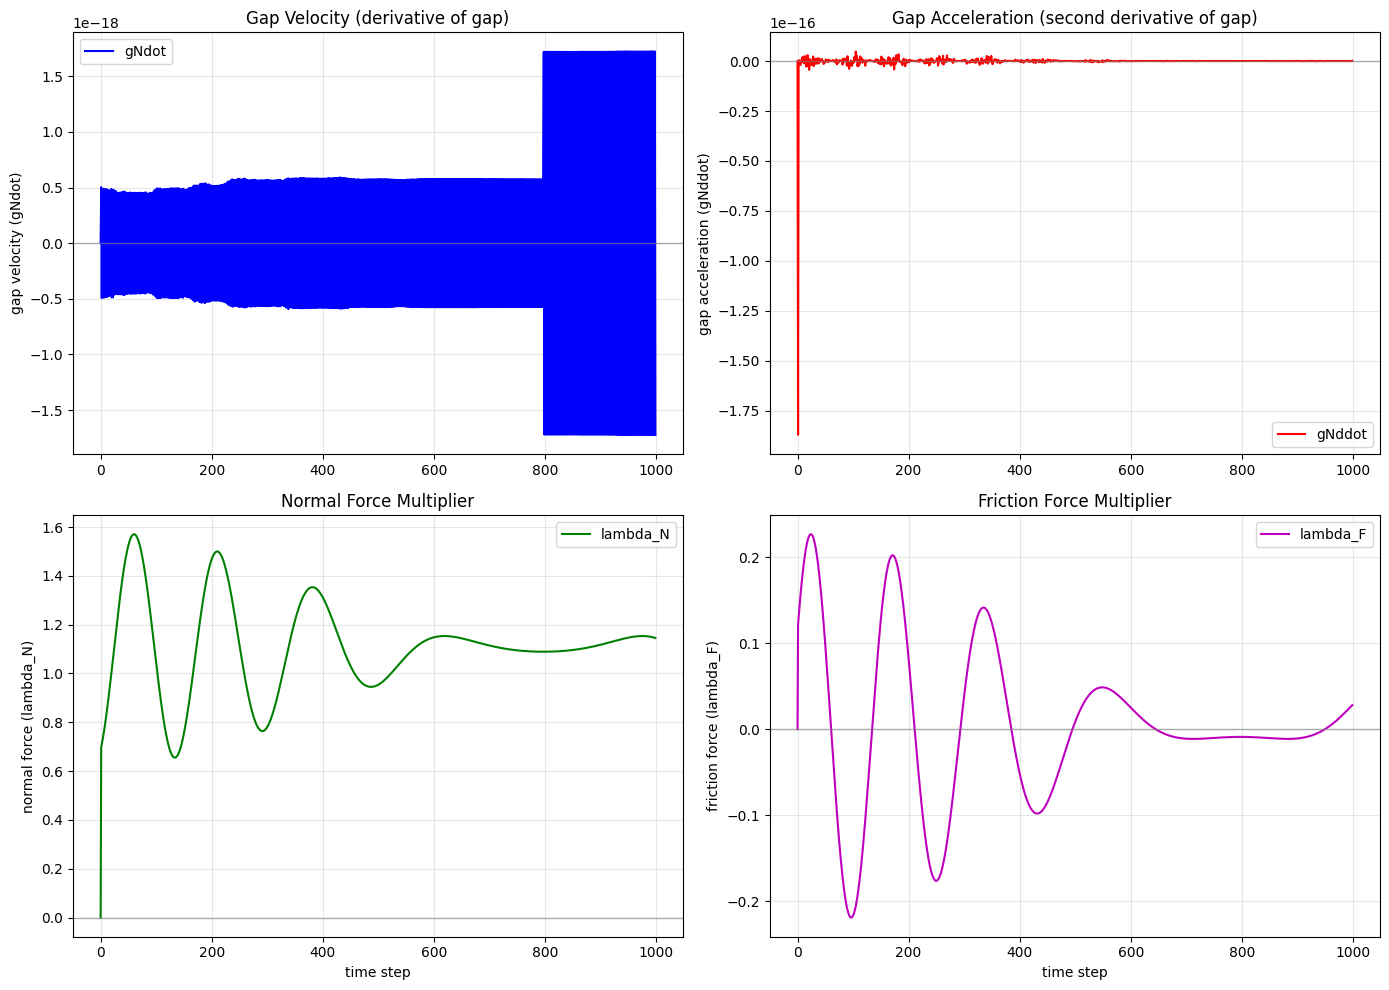

In [142]:
# Load and plot gNdot, gNddot, lambda_F, lambda_N
gNdot = np.load(OUTPUT_DIR / "gNdot_save.npy")
gNddot = np.load(OUTPUT_DIR / "gNddot_save.npy")
lambdaN = np.load(OUTPUT_DIR / "lambdaN_save.npy")

# Try loading lambdaF_save.npy first, fall back to gammaF_save.npy for older simulations
try:
    lambdaF = np.load(OUTPUT_DIR / "lambdaF_save.npy")
except FileNotFoundError:
    lambdaF = np.load(OUTPUT_DIR / "gammaF_save.npy")

print("gNdot shape:", gNdot.shape)
print("gNddot shape:", gNddot.shape)
print("lambdaN shape:", lambdaN.shape)
print("lambdaF shape:", lambdaF.shape)

# Create figure with subplots
fig_forces = plt.figure(figsize=(14, 10))

# 1) gNdot (velocity of gap)
ax1 = fig_forces.add_subplot(2, 2, 1)
ax1.plot(gNdot[0, :], 'b-', lw=1.5, label='gNdot')
ax1.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax1.set_ylabel('gap velocity (gNdot)')
ax1.set_title('Gap Velocity (derivative of gap)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2) gNddot (acceleration of gap)
ax2 = fig_forces.add_subplot(2, 2, 2)
ax2.plot(gNddot[0, :], 'r-', lw=1.5, label='gNddot')
ax2.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax2.set_ylabel('gap acceleration (gNddot)')
ax2.set_title('Gap Acceleration (second derivative of gap)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3) lambda_N (normal force)
ax3 = fig_forces.add_subplot(2, 2, 3)
ax3.plot(lambdaN[0, :], 'g-', lw=1.5, label='lambda_N')
ax3.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax3.set_xlabel('time step')
ax3.set_ylabel('normal force (lambda_N)')
ax3.set_title('Normal Force Multiplier')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4) lambda_F (friction force)
ax4 = fig_forces.add_subplot(2, 2, 4)
ax4.plot(lambdaF[0, :], 'm-', lw=1.5, label='lambda_F')
ax4.axhline(0.0, color='gray', lw=1, alpha=0.6)
ax4.set_xlabel('time step')
ax4.set_ylabel('friction force (lambda_F)')
ax4.set_title('Friction Force Multiplier')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

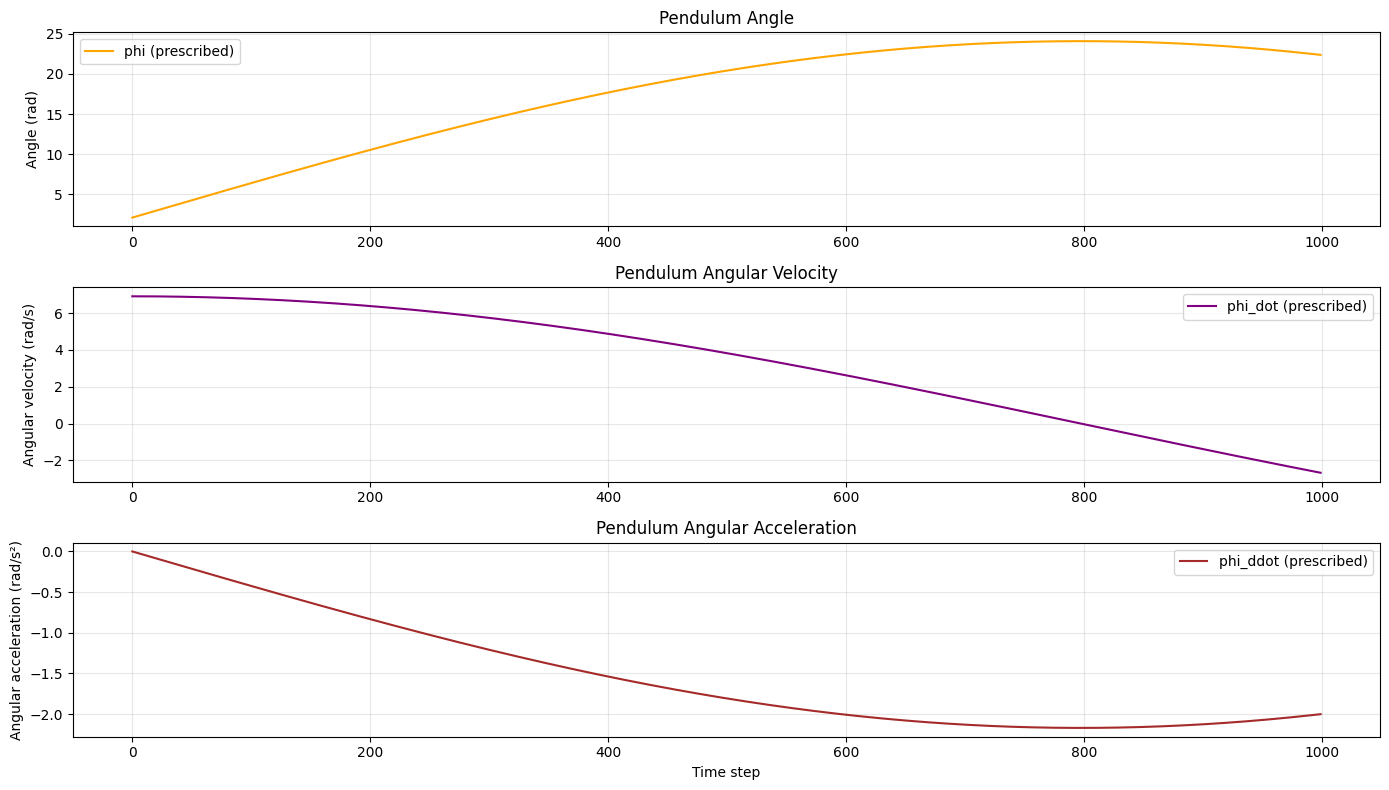

In [143]:
# Load and plot pendulum data
try:
    phi = np.load(OUTPUT_DIR / "phi_save.npy")
    phi_dot = np.load(OUTPUT_DIR / "phi_dot_save.npy")
    phi_ddot = np.load(OUTPUT_DIR / "phi_ddot_save.npy")
    
    fig_pend = plt.figure(figsize=(14, 8))
    
    # 1) Pendulum angle
    ax1 = fig_pend.add_subplot(3, 1, 1)
    ax1.plot(phi, 'orange', lw=1.5, label='phi (prescribed)')
    ax1.set_ylabel('Angle (rad)')
    ax1.set_title('Pendulum Angle')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2) Pendulum angular velocity
    ax2 = fig_pend.add_subplot(3, 1, 2)
    ax2.plot(phi_dot, 'purple', lw=1.5, label='phi_dot (prescribed)')
    ax2.set_ylabel('Angular velocity (rad/s)')
    ax2.set_title('Pendulum Angular Velocity')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3) Pendulum angular acceleration
    ax3 = fig_pend.add_subplot(3, 1, 3)
    ax3.plot(phi_ddot, 'brown', lw=1.5, label='phi_ddot (prescribed)')
    ax3.set_ylabel('Angular acceleration (rad/s²)')
    ax3.set_xlabel('Time step')
    ax3.set_title('Pendulum Angular Acceleration')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError as e:
    print(f"Pendulum data not found: {e}")


In [144]:
print("phi", phi[:50])

phi [2.0943951023931953 2.1377159071367062 2.1810365437698573
 2.224356844183195  2.2676766402684514 2.310995763919311
 2.3543140470301673 2.3976313215062737 2.4409474192454015
 2.484262172157486  2.527575412155782  2.5708869711594136
 2.614196681094031  2.6575043738924577 2.700809881495346
 2.744113035851827  2.787413668920165  2.830711612668407
 2.8740066990750375 2.917298760129629  2.9605876278334935
 3.0038731342003344 3.047155111256901  3.0904333910436366
 3.1337078056153334 3.176978187041783  3.2202443674084256
 3.2635061788170074 3.306763453386227  3.350016023252387
 3.393263720570051  3.436506377512687  3.479743826271429
 3.5229758990652047 3.5662024281224283 3.609423245700611
 3.652638184077532  3.6958470755537833 3.739049752453426
 3.7822460471246346 3.825435791940351  3.868618819298936
 3.9117949616248144 3.954964051369134  3.9981259210104074
 4.041280403053274  4.084427330036717  4.127566534523361
 4.170697849107695  4.213821106418602 ]
